![grouping](grouping_01262026.png)

<img src="https://cmse.msu.edu/_assets/images/about/image001.png"
     alt="CMSE Logo"
     align="right" 
     height="400" 
     width="400" />
# <font color=18453B>CMSE 801 - Day 13</font>
## Using Pandas to make an informed assessment based on data
### Exploring the Flint water crisis data
### Feb 24, 2026

## General Course Announcements

* Homework 2 is due **this Saturday**, Feb 28, by 11:59pm.
* Quiz 2 will take place on **this Thursday** (Feb 26).
    * The content of the quiz will cover concepts and assess knowledge that you demonstrated in Homework 2.
    * AI assistant is online. 
* Homework 3 will be posted today and is due **March 21**.

## Notes about homework submissions

* Make sure to read the assignment directions. Some lost points were simply a result of not doing what the question asked for or not doing all of the questions.
* Using a generative AI is perfectly acceptable in the course, but remember to include details about what tool you used and how you used it when you do (this include HiTA).
* Before you submit the file, you should make sure you do a "Kernel" -> "Restart and Clear Output" and then then re-run every cell in the note (in order) to make sure everything still works. Submit your notebook with all of the cells executed to simplify the grading process. 

## Questions/comments from Day 13 PCA

* Most common challengs were:
    * plotting: subplot, googling syntax, looping etc
    * using log scale
    * masking, selecting data


### Before we march on, let's import the modules we might use.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Let's review some of the plotting components and log scale

In [3]:
# First we need to load some data to work with
gdp = pd.read_csv("GDP_Cleaned.csv") 
gdp.head(10)

,Year,Africa Eastern and Southern,Africa Western and Central,Australia,Austria,Burundi,Belgium,Benin,Burkina Faso,Bangladesh,...,Turkiye,Uganda,Upper middle income,Uruguay,United States,St. Vincent and the Grenadines,World,South Africa,Zambia,Zimbabwe
0,1960,2.112502e+10,1.044764e+10,1.860656e+10,6.592694e+09,1.960000e+08,1.165872e+10,2.261956e+08,3.304428e+08,4.274894e+09,...,7.552471e+09,4.230084e+08,2.293135e+11,1.242289e+09,5.433000e+11,1.306663e+07,1.384857e+12,8.748597e+09,7.130000e+08,1.052990e+09
1,1961,2.161623e+10,1.117321e+10,1.968288e+10,7.311750e+09,2.030000e+08,1.240015e+10,2.356682e+08,3.502472e+08,4.817580e+09,...,7.971175e+09,4.415241e+08,2.175573e+11,1.547389e+09,5.633000e+11,1.399996e+07,1.449221e+12,9.225996e+09,6.962857e+08,1.096647e+09
2,1962,2.350628e+10,1.199053e+10,1.992256e+10,7.756110e+09,2.135000e+08,1.326402e+10,2.364350e+08,3.795671e+08,5.081413e+09,...,8.902439e+09,4.490126e+08,2.231230e+11,1.710004e+09,6.051000e+11,1.452496e+07,1.550815e+12,9.813996e+09,6.931429e+08,1.117602e+09
3,1963,2.804836e+10,1.272769e+10,2.153984e+10,8.374175e+09,2.327500e+08,1.426002e+10,2.539277e+08,3.940407e+08,5.319458e+09,...,1.033259e+10,5.161478e+08,2.341295e+11,1.539681e+09,6.386000e+11,1.370830e+07,1.671447e+12,1.085420e+10,7.187143e+08,1.159512e+09
4,1964,2.592067e+10,1.389811e+10,2.380112e+10,9.169984e+09,2.607500e+08,1.596011e+10,2.698190e+08,4.103216e+08,5.386055e+09,...,1.112934e+10,5.890566e+08,2.686610e+11,1.975702e+09,6.858000e+11,1.475830e+07,1.830492e+12,1.195600e+10,8.394286e+08,1.217138e+09
5,1965,2.947210e+10,1.492979e+10,2.597616e+10,9.994071e+09,1.589950e+08,1.737146e+10,2.899087e+08,4.229168e+08,5.906637e+09,...,1.191372e+10,8.845023e+08,3.001435e+11,1.890767e+09,7.437000e+11,1.510830e+07,1.994103e+12,1.306899e+10,1.082857e+09,1.311436e+09
6,1966,3.201437e+10,1.591084e+10,2.730784e+10,1.088768e+10,1.654446e+08,1.865188e+10,3.029252e+08,4.338898e+08,6.439688e+09,...,1.403761e+10,9.253815e+08,3.315427e+11,1.809185e+09,8.150000e+11,1.609996e+07,2.164118e+12,1.421139e+10,1.264286e+09,1.281750e+09
7,1967,3.326951e+10,1.451058e+10,3.044272e+10,1.157943e+10,1.782971e+08,1.999204e+10,3.062220e+08,4.507539e+08,7.253575e+09,...,1.557522e+10,9.672407e+08,3.336424e+11,1.597713e+09,8.617000e+11,1.583510e+07,2.302577e+12,1.582139e+10,1.368000e+09,1.397002e+09
8,1968,3.632779e+10,1.496824e+10,3.271409e+10,1.244063e+10,1.832000e+08,2.137635e+10,3.263231e+08,4.604427e+08,7.483685e+09,...,1.742257e+10,1.037379e+09,3.501150e+11,1.593674e+09,9.425000e+11,1.535000e+07,2.484674e+12,1.712479e+10,1.605857e+09,1.479600e+09
9,1969,4.163897e+10,1.697932e+10,3.668337e+10,1.358280e+10,1.902057e+08,2.371074e+10,3.307482e+08,4.782986e+08,8.471006e+09,...,1.938053e+10,1.168557e+09,3.928095e+11,2.004435e+09,1.019900e+12,1.665000e+07,2.740499e+12,1.925699e+10,1.965714e+09,1.747999e+09


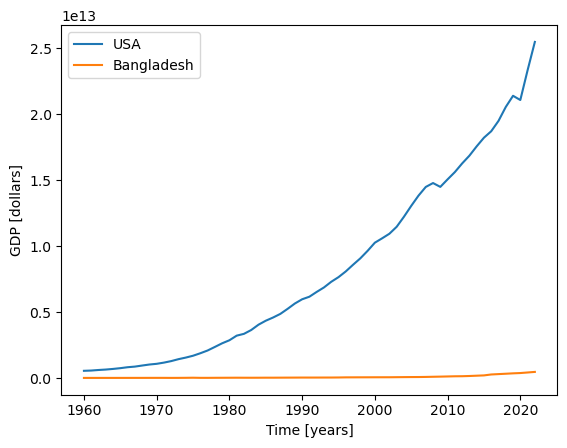

In [4]:
plt.plot(gdp["Year"],gdp['United States'],label="USA")
plt.plot(gdp["Year"],gdp['Bangladesh'], label="Bangladesh")
plt.xlabel("Time [years]")
plt.ylabel("GDP [dollars]")
plt.legend();

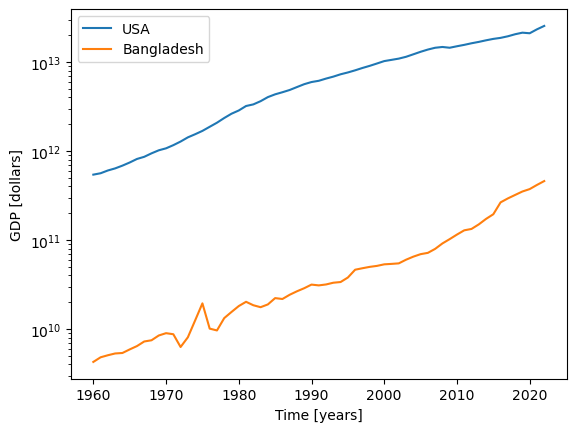

In [6]:
plt.plot(gdp["Year"],gdp['United States'],label="USA")
plt.plot(gdp["Year"],gdp['Bangladesh'], label="Bangladesh")
plt.yscale("log")
plt.xlabel("Time [years]")
plt.ylabel("GDP [dollars]")
plt.legend();

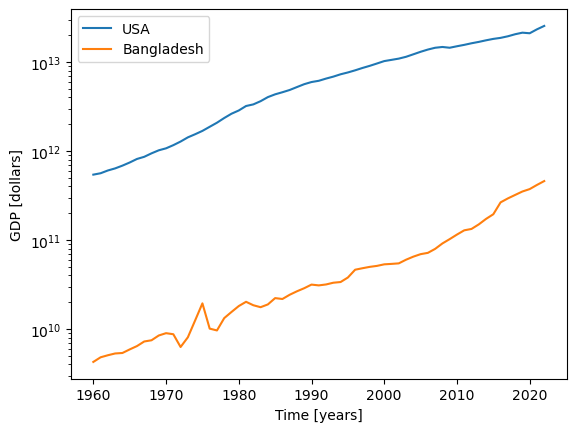

In [7]:
plt.semilogy(gdp["Year"],gdp['United States'],label="USA")
plt.semilogy(gdp["Year"],gdp['Bangladesh'], label="Bangladesh")
plt.xlabel("Time [years]")
plt.ylabel("GDP [dollars]")
plt.legend();

### Using subplots

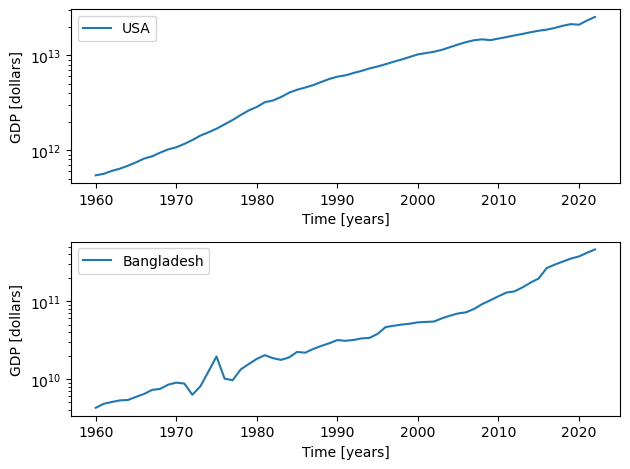

In [9]:
plt.figure(1)
plt.subplot(211)
plt.semilogy(gdp["Year"],gdp['United States'],label="USA")
plt.xlabel("Time [years]")
plt.ylabel("GDP [dollars]")
plt.legend();

plt.subplot(212)
plt.semilogy(gdp["Year"],gdp['Bangladesh'], label="Bangladesh")
plt.xlabel("Time [years]")
plt.ylabel("GDP [dollars]")
plt.legend();

plt.tight_layout();

### Let's do a little bit of experimentation with masks

In [10]:
# Let's generate some fake data
my_data = np.random.randint(low=0,high=100,size=100) 
print(my_data)

[18 90 87 21 79 26 84 82 12  2 57 96 87 99 76 23 28 91 73 99 99 20 90 99
 58 63 63 18 46 55 24 94 90 56 62 28 66 51 93 57 92 39 47 28 67 42 91 70
 13 50 12 23 15 51 98 18 61  1  4 58 21 37 47 62 48 58 52 19  5 64 16 43
 88 95 91 11 23 60 94 89 20 16 61 41 90 45 55 37 56 32 55 43  5 61 68 36
 23 91 31 66]


In [12]:
mask = my_data > 25
# print(mask)
print(my_data[mask])
print("Number of values greater than 25:", len(my_data[mask]))

[90 87 79 26 84 82 57 96 87 99 76 28 91 73 99 99 90 99 58 63 63 46 55 94
 90 56 62 28 66 51 93 57 92 39 47 28 67 42 91 70 50 51 98 61 58 37 47 62
 48 58 52 64 43 88 95 91 60 94 89 61 41 90 45 55 37 56 32 55 43 61 68 36
 91 31 66]
Number of values greater than 25: 75


In [13]:
mask = my_data == 25
print(mask)
print(my_data[mask])
print("Number of values equal to 25:", len(my_data[mask]))

[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False]
[]
Number of values equal to 25: 0


In [ ]:
mask1 = my_data > 25
mask1_data = my_data[mask1]
mask2 = mask1_data < 75
mask1and2_data = mask1_data[mask2]
print(mask1and2_data)
print("Number of values between 25 and 75:", len(mask1and2_data))

In [14]:
mask_both = (my_data > 25) & (my_data < 75) # this uses a bitwise "AND"
masked_data = my_data[mask_both]
print(masked_data)
print("Number of values between 25 and 75:", len(masked_data))

[26 57 28 73 58 63 63 46 55 56 62 28 66 51 57 39 47 28 67 42 70 50 51 61
 58 37 47 62 48 58 52 64 43 60 61 41 45 55 37 56 32 55 43 61 68 36 31 66]
Number of values between 25 and 75: 48


This is using something we haven't seen/talked about, which are ["bitwise" operators](https://www.w3schools.com/python/gloss_python_bitwise_operators.asp) in Python.

In [ ]:
mask_both = (my_data < 25) | (my_data > 75) # this use a bitwise "OR"
masked_data = my_data[mask_both]
print(masked_data)
print("Number of values less 25 and greater 75:", len(masked_data))

### We can also be a bit lazier and save ourselves some lines of code...

In [ ]:
print(my_data[my_data>25]) # the mask I was using before is directly placed inside the []'s
print("Number of values greater than 25:", len(my_data[my_data>25]))

### We can using masks with Pandas data as well!

In [15]:
from io import StringIO
# read in some data on heart disease
heart_disease_data = pd.read_json(StringIO("""[{"observation_number":0,"age":67,"sex":1,"cp":4,"trestbps":160,"chol":286,"fbs":0,"restecg":2,"thalach":108,"exang":1,"oldpeak":1.5,"slope":2,"ca":"3.0","thal":"3.0","num":2},{"observation_number":1,"age":67,"sex":1,"cp":4,"trestbps":120,"chol":229,"fbs":0,"restecg":2,"thalach":129,"exang":1,"oldpeak":2.6,"slope":2,"ca":"2.0","thal":"7.0","num":1},{"observation_number":2,"age":37,"sex":1,"cp":3,"trestbps":130,"chol":250,"fbs":0,"restecg":0,"thalach":187,"exang":0,"oldpeak":3.5,"slope":3,"ca":"0.0","thal":"3.0","num":0},{"observation_number":3,"age":41,"sex":0,"cp":2,"trestbps":130,"chol":204,"fbs":0,"restecg":2,"thalach":172,"exang":0,"oldpeak":1.4,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":4,"age":56,"sex":1,"cp":2,"trestbps":120,"chol":236,"fbs":0,"restecg":0,"thalach":178,"exang":0,"oldpeak":0.8,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":5,"age":62,"sex":0,"cp":4,"trestbps":140,"chol":268,"fbs":0,"restecg":2,"thalach":160,"exang":0,"oldpeak":3.6,"slope":3,"ca":"2.0","thal":"3.0","num":3},{"observation_number":6,"age":57,"sex":0,"cp":4,"trestbps":120,"chol":354,"fbs":0,"restecg":0,"thalach":163,"exang":1,"oldpeak":0.6,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":7,"age":63,"sex":1,"cp":4,"trestbps":130,"chol":254,"fbs":0,"restecg":2,"thalach":147,"exang":0,"oldpeak":1.4,"slope":2,"ca":"1.0","thal":"7.0","num":2},{"observation_number":8,"age":53,"sex":1,"cp":4,"trestbps":140,"chol":203,"fbs":1,"restecg":2,"thalach":155,"exang":1,"oldpeak":3.1,"slope":3,"ca":"0.0","thal":"7.0","num":1},{"observation_number":9,"age":57,"sex":1,"cp":4,"trestbps":140,"chol":192,"fbs":0,"restecg":0,"thalach":148,"exang":0,"oldpeak":0.4,"slope":2,"ca":"0.0","thal":"6.0","num":0},{"observation_number":10,"age":56,"sex":0,"cp":2,"trestbps":140,"chol":294,"fbs":0,"restecg":2,"thalach":153,"exang":0,"oldpeak":1.3,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":11,"age":56,"sex":1,"cp":3,"trestbps":130,"chol":256,"fbs":1,"restecg":2,"thalach":142,"exang":1,"oldpeak":0.6,"slope":2,"ca":"1.0","thal":"6.0","num":2},{"observation_number":12,"age":44,"sex":1,"cp":2,"trestbps":120,"chol":263,"fbs":0,"restecg":0,"thalach":173,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"7.0","num":0},{"observation_number":13,"age":52,"sex":1,"cp":3,"trestbps":172,"chol":199,"fbs":1,"restecg":0,"thalach":162,"exang":0,"oldpeak":0.5,"slope":1,"ca":"0.0","thal":"7.0","num":0},{"observation_number":14,"age":57,"sex":1,"cp":3,"trestbps":150,"chol":168,"fbs":0,"restecg":0,"thalach":174,"exang":0,"oldpeak":1.6,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":15,"age":48,"sex":1,"cp":2,"trestbps":110,"chol":229,"fbs":0,"restecg":0,"thalach":168,"exang":0,"oldpeak":1,"slope":3,"ca":"0.0","thal":"7.0","num":1},{"observation_number":16,"age":54,"sex":1,"cp":4,"trestbps":140,"chol":239,"fbs":0,"restecg":0,"thalach":160,"exang":0,"oldpeak":1.2,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":17,"age":48,"sex":0,"cp":3,"trestbps":130,"chol":275,"fbs":0,"restecg":0,"thalach":139,"exang":0,"oldpeak":0.2,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":18,"age":49,"sex":1,"cp":2,"trestbps":130,"chol":266,"fbs":0,"restecg":0,"thalach":171,"exang":0,"oldpeak":0.6,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":19,"age":64,"sex":1,"cp":1,"trestbps":110,"chol":211,"fbs":0,"restecg":2,"thalach":144,"exang":1,"oldpeak":1.8,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":20,"age":58,"sex":0,"cp":1,"trestbps":150,"chol":283,"fbs":1,"restecg":2,"thalach":162,"exang":0,"oldpeak":1,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":21,"age":58,"sex":1,"cp":2,"trestbps":120,"chol":284,"fbs":0,"restecg":2,"thalach":160,"exang":0,"oldpeak":1.8,"slope":2,"ca":"0.0","thal":"3.0","num":1},{"observation_number":22,"age":58,"sex":1,"cp":3,"trestbps":132,"chol":224,"fbs":0,"restecg":2,"thalach":173,"exang":0,"oldpeak":3.2,"slope":1,"ca":"2.0","thal":"7.0","num":3},{"observation_number":23,"age":60,"sex":1,"cp":4,"trestbps":130,"chol":206,"fbs":0,"restecg":2,"thalach":132,"exang":1,"oldpeak":2.4,"slope":2,"ca":"2.0","thal":"7.0","num":4},{"observation_number":24,"age":50,"sex":0,"cp":3,"trestbps":120,"chol":219,"fbs":0,"restecg":0,"thalach":158,"exang":0,"oldpeak":1.6,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":25,"age":58,"sex":0,"cp":3,"trestbps":120,"chol":340,"fbs":0,"restecg":0,"thalach":172,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":26,"age":66,"sex":0,"cp":1,"trestbps":150,"chol":226,"fbs":0,"restecg":0,"thalach":114,"exang":0,"oldpeak":2.6,"slope":3,"ca":"0.0","thal":"3.0","num":0},{"observation_number":27,"age":43,"sex":1,"cp":4,"trestbps":150,"chol":247,"fbs":0,"restecg":0,"thalach":171,"exang":0,"oldpeak":1.5,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":28,"age":40,"sex":1,"cp":4,"trestbps":110,"chol":167,"fbs":0,"restecg":2,"thalach":114,"exang":1,"oldpeak":2,"slope":2,"ca":"0.0","thal":"7.0","num":3},{"observation_number":29,"age":69,"sex":0,"cp":1,"trestbps":140,"chol":239,"fbs":0,"restecg":0,"thalach":151,"exang":0,"oldpeak":1.8,"slope":1,"ca":"2.0","thal":"3.0","num":0},{"observation_number":30,"age":60,"sex":1,"cp":4,"trestbps":117,"chol":230,"fbs":1,"restecg":0,"thalach":160,"exang":1,"oldpeak":1.4,"slope":1,"ca":"2.0","thal":"7.0","num":2},{"observation_number":31,"age":64,"sex":1,"cp":3,"trestbps":140,"chol":335,"fbs":0,"restecg":0,"thalach":158,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":1},{"observation_number":32,"age":59,"sex":1,"cp":4,"trestbps":135,"chol":234,"fbs":0,"restecg":0,"thalach":161,"exang":0,"oldpeak":0.5,"slope":2,"ca":"0.0","thal":"7.0","num":0},{"observation_number":33,"age":44,"sex":1,"cp":3,"trestbps":130,"chol":233,"fbs":0,"restecg":0,"thalach":179,"exang":1,"oldpeak":0.4,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":34,"age":42,"sex":1,"cp":4,"trestbps":140,"chol":226,"fbs":0,"restecg":0,"thalach":178,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":35,"age":43,"sex":1,"cp":4,"trestbps":120,"chol":177,"fbs":0,"restecg":2,"thalach":120,"exang":1,"oldpeak":2.5,"slope":2,"ca":"0.0","thal":"7.0","num":3},{"observation_number":36,"age":57,"sex":1,"cp":4,"trestbps":150,"chol":276,"fbs":0,"restecg":2,"thalach":112,"exang":1,"oldpeak":0.6,"slope":2,"ca":"1.0","thal":"6.0","num":1},{"observation_number":37,"age":55,"sex":1,"cp":4,"trestbps":132,"chol":353,"fbs":0,"restecg":0,"thalach":132,"exang":1,"oldpeak":1.2,"slope":2,"ca":"1.0","thal":"7.0","num":3},{"observation_number":38,"age":61,"sex":1,"cp":3,"trestbps":150,"chol":243,"fbs":1,"restecg":0,"thalach":137,"exang":1,"oldpeak":1,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":39,"age":65,"sex":0,"cp":4,"trestbps":150,"chol":225,"fbs":0,"restecg":2,"thalach":114,"exang":0,"oldpeak":1,"slope":2,"ca":"3.0","thal":"7.0","num":4},{"observation_number":40,"age":40,"sex":1,"cp":1,"trestbps":140,"chol":199,"fbs":0,"restecg":0,"thalach":178,"exang":1,"oldpeak":1.4,"slope":1,"ca":"0.0","thal":"7.0","num":0},{"observation_number":41,"age":71,"sex":0,"cp":2,"trestbps":160,"chol":302,"fbs":0,"restecg":0,"thalach":162,"exang":0,"oldpeak":0.4,"slope":1,"ca":"2.0","thal":"3.0","num":0},{"observation_number":42,"age":59,"sex":1,"cp":3,"trestbps":150,"chol":212,"fbs":1,"restecg":0,"thalach":157,"exang":0,"oldpeak":1.6,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":43,"age":61,"sex":0,"cp":4,"trestbps":130,"chol":330,"fbs":0,"restecg":2,"thalach":169,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":1},{"observation_number":44,"age":58,"sex":1,"cp":3,"trestbps":112,"chol":230,"fbs":0,"restecg":2,"thalach":165,"exang":0,"oldpeak":2.5,"slope":2,"ca":"1.0","thal":"7.0","num":4},{"observation_number":45,"age":51,"sex":1,"cp":3,"trestbps":110,"chol":175,"fbs":0,"restecg":0,"thalach":123,"exang":0,"oldpeak":0.6,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":46,"age":50,"sex":1,"cp":4,"trestbps":150,"chol":243,"fbs":0,"restecg":2,"thalach":128,"exang":0,"oldpeak":2.6,"slope":2,"ca":"0.0","thal":"7.0","num":4},{"observation_number":47,"age":65,"sex":0,"cp":3,"trestbps":140,"chol":417,"fbs":1,"restecg":2,"thalach":157,"exang":0,"oldpeak":0.8,"slope":1,"ca":"1.0","thal":"3.0","num":0},{"observation_number":48,"age":53,"sex":1,"cp":3,"trestbps":130,"chol":197,"fbs":1,"restecg":2,"thalach":152,"exang":0,"oldpeak":1.2,"slope":3,"ca":"0.0","thal":"3.0","num":0},{"observation_number":49,"age":41,"sex":0,"cp":2,"trestbps":105,"chol":198,"fbs":0,"restecg":0,"thalach":168,"exang":0,"oldpeak":0,"slope":1,"ca":"1.0","thal":"3.0","num":0},{"observation_number":50,"age":65,"sex":1,"cp":4,"trestbps":120,"chol":177,"fbs":0,"restecg":0,"thalach":140,"exang":0,"oldpeak":0.4,"slope":1,"ca":"0.0","thal":"7.0","num":0},{"observation_number":51,"age":44,"sex":1,"cp":4,"trestbps":112,"chol":290,"fbs":0,"restecg":2,"thalach":153,"exang":0,"oldpeak":0,"slope":1,"ca":"1.0","thal":"3.0","num":2},{"observation_number":52,"age":44,"sex":1,"cp":2,"trestbps":130,"chol":219,"fbs":0,"restecg":2,"thalach":188,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":53,"age":60,"sex":1,"cp":4,"trestbps":130,"chol":253,"fbs":0,"restecg":0,"thalach":144,"exang":1,"oldpeak":1.4,"slope":1,"ca":"1.0","thal":"7.0","num":1},{"observation_number":54,"age":54,"sex":1,"cp":4,"trestbps":124,"chol":266,"fbs":0,"restecg":2,"thalach":109,"exang":1,"oldpeak":2.2,"slope":2,"ca":"1.0","thal":"7.0","num":1},{"observation_number":55,"age":50,"sex":1,"cp":3,"trestbps":140,"chol":233,"fbs":0,"restecg":0,"thalach":163,"exang":0,"oldpeak":0.6,"slope":2,"ca":"1.0","thal":"7.0","num":1},{"observation_number":56,"age":41,"sex":1,"cp":4,"trestbps":110,"chol":172,"fbs":0,"restecg":2,"thalach":158,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"7.0","num":1},{"observation_number":57,"age":54,"sex":1,"cp":3,"trestbps":125,"chol":273,"fbs":0,"restecg":2,"thalach":152,"exang":0,"oldpeak":0.5,"slope":3,"ca":"1.0","thal":"3.0","num":0},{"observation_number":58,"age":51,"sex":1,"cp":1,"trestbps":125,"chol":213,"fbs":0,"restecg":2,"thalach":125,"exang":1,"oldpeak":1.4,"slope":1,"ca":"1.0","thal":"3.0","num":0},{"observation_number":59,"age":51,"sex":0,"cp":4,"trestbps":130,"chol":305,"fbs":0,"restecg":0,"thalach":142,"exang":1,"oldpeak":1.2,"slope":2,"ca":"0.0","thal":"7.0","num":2},{"observation_number":60,"age":46,"sex":0,"cp":3,"trestbps":142,"chol":177,"fbs":0,"restecg":2,"thalach":160,"exang":1,"oldpeak":1.4,"slope":3,"ca":"0.0","thal":"3.0","num":0},{"observation_number":61,"age":58,"sex":1,"cp":4,"trestbps":128,"chol":216,"fbs":0,"restecg":2,"thalach":131,"exang":1,"oldpeak":2.2,"slope":2,"ca":"3.0","thal":"7.0","num":1},{"observation_number":62,"age":54,"sex":0,"cp":3,"trestbps":135,"chol":304,"fbs":1,"restecg":0,"thalach":170,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":63,"age":54,"sex":1,"cp":4,"trestbps":120,"chol":188,"fbs":0,"restecg":0,"thalach":113,"exang":0,"oldpeak":1.4,"slope":2,"ca":"1.0","thal":"7.0","num":2},{"observation_number":64,"age":60,"sex":1,"cp":4,"trestbps":145,"chol":282,"fbs":0,"restecg":2,"thalach":142,"exang":1,"oldpeak":2.8,"slope":2,"ca":"2.0","thal":"7.0","num":2},{"observation_number":65,"age":60,"sex":1,"cp":3,"trestbps":140,"chol":185,"fbs":0,"restecg":2,"thalach":155,"exang":0,"oldpeak":3,"slope":2,"ca":"0.0","thal":"3.0","num":1},{"observation_number":66,"age":54,"sex":1,"cp":3,"trestbps":150,"chol":232,"fbs":0,"restecg":2,"thalach":165,"exang":0,"oldpeak":1.6,"slope":1,"ca":"0.0","thal":"7.0","num":0},{"observation_number":67,"age":59,"sex":1,"cp":4,"trestbps":170,"chol":326,"fbs":0,"restecg":2,"thalach":140,"exang":1,"oldpeak":3.4,"slope":3,"ca":"0.0","thal":"7.0","num":2},{"observation_number":68,"age":46,"sex":1,"cp":3,"trestbps":150,"chol":231,"fbs":0,"restecg":0,"thalach":147,"exang":0,"oldpeak":3.6,"slope":2,"ca":"0.0","thal":"3.0","num":1},{"observation_number":69,"age":65,"sex":0,"cp":3,"trestbps":155,"chol":269,"fbs":0,"restecg":0,"thalach":148,"exang":0,"oldpeak":0.8,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":70,"age":67,"sex":1,"cp":4,"trestbps":125,"chol":254,"fbs":1,"restecg":0,"thalach":163,"exang":0,"oldpeak":0.2,"slope":2,"ca":"2.0","thal":"7.0","num":3},{"observation_number":71,"age":62,"sex":1,"cp":4,"trestbps":120,"chol":267,"fbs":0,"restecg":0,"thalach":99,"exang":1,"oldpeak":1.8,"slope":2,"ca":"2.0","thal":"7.0","num":1},{"observation_number":72,"age":65,"sex":1,"cp":4,"trestbps":110,"chol":248,"fbs":0,"restecg":2,"thalach":158,"exang":0,"oldpeak":0.6,"slope":1,"ca":"2.0","thal":"6.0","num":1},{"observation_number":73,"age":44,"sex":1,"cp":4,"trestbps":110,"chol":197,"fbs":0,"restecg":2,"thalach":177,"exang":0,"oldpeak":0,"slope":1,"ca":"1.0","thal":"3.0","num":1},{"observation_number":74,"age":65,"sex":0,"cp":3,"trestbps":160,"chol":360,"fbs":0,"restecg":2,"thalach":151,"exang":0,"oldpeak":0.8,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":75,"age":60,"sex":1,"cp":4,"trestbps":125,"chol":258,"fbs":0,"restecg":2,"thalach":141,"exang":1,"oldpeak":2.8,"slope":2,"ca":"1.0","thal":"7.0","num":1},{"observation_number":76,"age":51,"sex":0,"cp":3,"trestbps":140,"chol":308,"fbs":0,"restecg":2,"thalach":142,"exang":0,"oldpeak":1.5,"slope":1,"ca":"1.0","thal":"3.0","num":0},{"observation_number":77,"age":48,"sex":1,"cp":2,"trestbps":130,"chol":245,"fbs":0,"restecg":2,"thalach":180,"exang":0,"oldpeak":0.2,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":78,"age":58,"sex":1,"cp":4,"trestbps":150,"chol":270,"fbs":0,"restecg":2,"thalach":111,"exang":1,"oldpeak":0.8,"slope":1,"ca":"0.0","thal":"7.0","num":3},{"observation_number":79,"age":45,"sex":1,"cp":4,"trestbps":104,"chol":208,"fbs":0,"restecg":2,"thalach":148,"exang":1,"oldpeak":3,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":80,"age":53,"sex":0,"cp":4,"trestbps":130,"chol":264,"fbs":0,"restecg":2,"thalach":143,"exang":0,"oldpeak":0.4,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":81,"age":39,"sex":1,"cp":3,"trestbps":140,"chol":321,"fbs":0,"restecg":2,"thalach":182,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":82,"age":68,"sex":1,"cp":3,"trestbps":180,"chol":274,"fbs":1,"restecg":2,"thalach":150,"exang":1,"oldpeak":1.6,"slope":2,"ca":"0.0","thal":"7.0","num":3},{"observation_number":83,"age":52,"sex":1,"cp":2,"trestbps":120,"chol":325,"fbs":0,"restecg":0,"thalach":172,"exang":0,"oldpeak":0.2,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":84,"age":44,"sex":1,"cp":3,"trestbps":140,"chol":235,"fbs":0,"restecg":2,"thalach":180,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":85,"age":47,"sex":1,"cp":3,"trestbps":138,"chol":257,"fbs":0,"restecg":2,"thalach":156,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":86,"age":53,"sex":0,"cp":3,"trestbps":128,"chol":216,"fbs":0,"restecg":2,"thalach":115,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"?","num":0},{"observation_number":87,"age":53,"sex":0,"cp":4,"trestbps":138,"chol":234,"fbs":0,"restecg":2,"thalach":160,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":88,"age":51,"sex":0,"cp":3,"trestbps":130,"chol":256,"fbs":0,"restecg":2,"thalach":149,"exang":0,"oldpeak":0.5,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":89,"age":66,"sex":1,"cp":4,"trestbps":120,"chol":302,"fbs":0,"restecg":2,"thalach":151,"exang":0,"oldpeak":0.4,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":90,"age":62,"sex":0,"cp":4,"trestbps":160,"chol":164,"fbs":0,"restecg":2,"thalach":145,"exang":0,"oldpeak":6.2,"slope":3,"ca":"3.0","thal":"7.0","num":3},{"observation_number":91,"age":62,"sex":1,"cp":3,"trestbps":130,"chol":231,"fbs":0,"restecg":0,"thalach":146,"exang":0,"oldpeak":1.8,"slope":2,"ca":"3.0","thal":"7.0","num":0},{"observation_number":92,"age":44,"sex":0,"cp":3,"trestbps":108,"chol":141,"fbs":0,"restecg":0,"thalach":175,"exang":0,"oldpeak":0.6,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":93,"age":63,"sex":0,"cp":3,"trestbps":135,"chol":252,"fbs":0,"restecg":2,"thalach":172,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":94,"age":52,"sex":1,"cp":4,"trestbps":128,"chol":255,"fbs":0,"restecg":0,"thalach":161,"exang":1,"oldpeak":0,"slope":1,"ca":"1.0","thal":"7.0","num":1},{"observation_number":95,"age":59,"sex":1,"cp":4,"trestbps":110,"chol":239,"fbs":0,"restecg":2,"thalach":142,"exang":1,"oldpeak":1.2,"slope":2,"ca":"1.0","thal":"7.0","num":2},{"observation_number":96,"age":60,"sex":0,"cp":4,"trestbps":150,"chol":258,"fbs":0,"restecg":2,"thalach":157,"exang":0,"oldpeak":2.6,"slope":2,"ca":"2.0","thal":"7.0","num":3},{"observation_number":97,"age":52,"sex":1,"cp":2,"trestbps":134,"chol":201,"fbs":0,"restecg":0,"thalach":158,"exang":0,"oldpeak":0.8,"slope":1,"ca":"1.0","thal":"3.0","num":0},{"observation_number":98,"age":48,"sex":1,"cp":4,"trestbps":122,"chol":222,"fbs":0,"restecg":2,"thalach":186,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":99,"age":45,"sex":1,"cp":4,"trestbps":115,"chol":260,"fbs":0,"restecg":2,"thalach":185,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":100,"age":34,"sex":1,"cp":1,"trestbps":118,"chol":182,"fbs":0,"restecg":2,"thalach":174,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":101,"age":57,"sex":0,"cp":4,"trestbps":128,"chol":303,"fbs":0,"restecg":2,"thalach":159,"exang":0,"oldpeak":0,"slope":1,"ca":"1.0","thal":"3.0","num":0},{"observation_number":102,"age":71,"sex":0,"cp":3,"trestbps":110,"chol":265,"fbs":1,"restecg":2,"thalach":130,"exang":0,"oldpeak":0,"slope":1,"ca":"1.0","thal":"3.0","num":0},{"observation_number":103,"age":49,"sex":1,"cp":3,"trestbps":120,"chol":188,"fbs":0,"restecg":0,"thalach":139,"exang":0,"oldpeak":2,"slope":2,"ca":"3.0","thal":"7.0","num":3},{"observation_number":104,"age":54,"sex":1,"cp":2,"trestbps":108,"chol":309,"fbs":0,"restecg":0,"thalach":156,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"7.0","num":0},{"observation_number":105,"age":59,"sex":1,"cp":4,"trestbps":140,"chol":177,"fbs":0,"restecg":0,"thalach":162,"exang":1,"oldpeak":0,"slope":1,"ca":"1.0","thal":"7.0","num":2},{"observation_number":106,"age":57,"sex":1,"cp":3,"trestbps":128,"chol":229,"fbs":0,"restecg":2,"thalach":150,"exang":0,"oldpeak":0.4,"slope":2,"ca":"1.0","thal":"7.0","num":1},{"observation_number":107,"age":61,"sex":1,"cp":4,"trestbps":120,"chol":260,"fbs":0,"restecg":0,"thalach":140,"exang":1,"oldpeak":3.6,"slope":2,"ca":"1.0","thal":"7.0","num":2},{"observation_number":108,"age":39,"sex":1,"cp":4,"trestbps":118,"chol":219,"fbs":0,"restecg":0,"thalach":140,"exang":0,"oldpeak":1.2,"slope":2,"ca":"0.0","thal":"7.0","num":3},{"observation_number":109,"age":61,"sex":0,"cp":4,"trestbps":145,"chol":307,"fbs":0,"restecg":2,"thalach":146,"exang":1,"oldpeak":1,"slope":2,"ca":"0.0","thal":"7.0","num":1},{"observation_number":110,"age":56,"sex":1,"cp":4,"trestbps":125,"chol":249,"fbs":1,"restecg":2,"thalach":144,"exang":1,"oldpeak":1.2,"slope":2,"ca":"1.0","thal":"3.0","num":1},{"observation_number":111,"age":52,"sex":1,"cp":1,"trestbps":118,"chol":186,"fbs":0,"restecg":2,"thalach":190,"exang":0,"oldpeak":0,"slope":2,"ca":"0.0","thal":"6.0","num":0},{"observation_number":112,"age":43,"sex":0,"cp":4,"trestbps":132,"chol":341,"fbs":1,"restecg":2,"thalach":136,"exang":1,"oldpeak":3,"slope":2,"ca":"0.0","thal":"7.0","num":2},{"observation_number":113,"age":62,"sex":0,"cp":3,"trestbps":130,"chol":263,"fbs":0,"restecg":0,"thalach":97,"exang":0,"oldpeak":1.2,"slope":2,"ca":"1.0","thal":"7.0","num":2},{"observation_number":114,"age":41,"sex":1,"cp":2,"trestbps":135,"chol":203,"fbs":0,"restecg":0,"thalach":132,"exang":0,"oldpeak":0,"slope":2,"ca":"0.0","thal":"6.0","num":0},{"observation_number":115,"age":58,"sex":1,"cp":3,"trestbps":140,"chol":211,"fbs":1,"restecg":2,"thalach":165,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":116,"age":35,"sex":0,"cp":4,"trestbps":138,"chol":183,"fbs":0,"restecg":0,"thalach":182,"exang":0,"oldpeak":1.4,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":117,"age":63,"sex":1,"cp":4,"trestbps":130,"chol":330,"fbs":1,"restecg":2,"thalach":132,"exang":1,"oldpeak":1.8,"slope":1,"ca":"3.0","thal":"7.0","num":3},{"observation_number":118,"age":65,"sex":1,"cp":4,"trestbps":135,"chol":254,"fbs":0,"restecg":2,"thalach":127,"exang":0,"oldpeak":2.8,"slope":2,"ca":"1.0","thal":"7.0","num":2},{"observation_number":119,"age":48,"sex":1,"cp":4,"trestbps":130,"chol":256,"fbs":1,"restecg":2,"thalach":150,"exang":1,"oldpeak":0,"slope":1,"ca":"2.0","thal":"7.0","num":3},{"observation_number":120,"age":63,"sex":0,"cp":4,"trestbps":150,"chol":407,"fbs":0,"restecg":2,"thalach":154,"exang":0,"oldpeak":4,"slope":2,"ca":"3.0","thal":"7.0","num":4},{"observation_number":121,"age":51,"sex":1,"cp":3,"trestbps":100,"chol":222,"fbs":0,"restecg":0,"thalach":143,"exang":1,"oldpeak":1.2,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":122,"age":55,"sex":1,"cp":4,"trestbps":140,"chol":217,"fbs":0,"restecg":0,"thalach":111,"exang":1,"oldpeak":5.6,"slope":3,"ca":"0.0","thal":"7.0","num":3},{"observation_number":123,"age":65,"sex":1,"cp":1,"trestbps":138,"chol":282,"fbs":1,"restecg":2,"thalach":174,"exang":0,"oldpeak":1.4,"slope":2,"ca":"1.0","thal":"3.0","num":1},{"observation_number":124,"age":45,"sex":0,"cp":2,"trestbps":130,"chol":234,"fbs":0,"restecg":2,"thalach":175,"exang":0,"oldpeak":0.6,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":125,"age":56,"sex":0,"cp":4,"trestbps":200,"chol":288,"fbs":1,"restecg":2,"thalach":133,"exang":1,"oldpeak":4,"slope":3,"ca":"2.0","thal":"7.0","num":3},{"observation_number":126,"age":54,"sex":1,"cp":4,"trestbps":110,"chol":239,"fbs":0,"restecg":0,"thalach":126,"exang":1,"oldpeak":2.8,"slope":2,"ca":"1.0","thal":"7.0","num":3},{"observation_number":127,"age":44,"sex":1,"cp":2,"trestbps":120,"chol":220,"fbs":0,"restecg":0,"thalach":170,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":128,"age":62,"sex":0,"cp":4,"trestbps":124,"chol":209,"fbs":0,"restecg":0,"thalach":163,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":129,"age":54,"sex":1,"cp":3,"trestbps":120,"chol":258,"fbs":0,"restecg":2,"thalach":147,"exang":0,"oldpeak":0.4,"slope":2,"ca":"0.0","thal":"7.0","num":0},{"observation_number":130,"age":51,"sex":1,"cp":3,"trestbps":94,"chol":227,"fbs":0,"restecg":0,"thalach":154,"exang":1,"oldpeak":0,"slope":1,"ca":"1.0","thal":"7.0","num":0},{"observation_number":131,"age":29,"sex":1,"cp":2,"trestbps":130,"chol":204,"fbs":0,"restecg":2,"thalach":202,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":132,"age":51,"sex":1,"cp":4,"trestbps":140,"chol":261,"fbs":0,"restecg":2,"thalach":186,"exang":1,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":133,"age":43,"sex":0,"cp":3,"trestbps":122,"chol":213,"fbs":0,"restecg":0,"thalach":165,"exang":0,"oldpeak":0.2,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":134,"age":55,"sex":0,"cp":2,"trestbps":135,"chol":250,"fbs":0,"restecg":2,"thalach":161,"exang":0,"oldpeak":1.4,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":135,"age":70,"sex":1,"cp":4,"trestbps":145,"chol":174,"fbs":0,"restecg":0,"thalach":125,"exang":1,"oldpeak":2.6,"slope":3,"ca":"0.0","thal":"7.0","num":4},{"observation_number":136,"age":62,"sex":1,"cp":2,"trestbps":120,"chol":281,"fbs":0,"restecg":2,"thalach":103,"exang":0,"oldpeak":1.4,"slope":2,"ca":"1.0","thal":"7.0","num":3},{"observation_number":137,"age":35,"sex":1,"cp":4,"trestbps":120,"chol":198,"fbs":0,"restecg":0,"thalach":130,"exang":1,"oldpeak":1.6,"slope":2,"ca":"0.0","thal":"7.0","num":1},{"observation_number":138,"age":51,"sex":1,"cp":3,"trestbps":125,"chol":245,"fbs":1,"restecg":2,"thalach":166,"exang":0,"oldpeak":2.4,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":139,"age":59,"sex":1,"cp":2,"trestbps":140,"chol":221,"fbs":0,"restecg":0,"thalach":164,"exang":1,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":140,"age":59,"sex":1,"cp":1,"trestbps":170,"chol":288,"fbs":0,"restecg":2,"thalach":159,"exang":0,"oldpeak":0.2,"slope":2,"ca":"0.0","thal":"7.0","num":1},{"observation_number":141,"age":52,"sex":1,"cp":2,"trestbps":128,"chol":205,"fbs":1,"restecg":0,"thalach":184,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":142,"age":64,"sex":1,"cp":3,"trestbps":125,"chol":309,"fbs":0,"restecg":0,"thalach":131,"exang":1,"oldpeak":1.8,"slope":2,"ca":"0.0","thal":"7.0","num":1},{"observation_number":143,"age":58,"sex":1,"cp":3,"trestbps":105,"chol":240,"fbs":0,"restecg":2,"thalach":154,"exang":1,"oldpeak":0.6,"slope":2,"ca":"0.0","thal":"7.0","num":0},{"observation_number":144,"age":47,"sex":1,"cp":3,"trestbps":108,"chol":243,"fbs":0,"restecg":0,"thalach":152,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":1},{"observation_number":145,"age":57,"sex":1,"cp":4,"trestbps":165,"chol":289,"fbs":1,"restecg":2,"thalach":124,"exang":0,"oldpeak":1,"slope":2,"ca":"3.0","thal":"7.0","num":4},{"observation_number":146,"age":41,"sex":1,"cp":3,"trestbps":112,"chol":250,"fbs":0,"restecg":0,"thalach":179,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":147,"age":45,"sex":1,"cp":2,"trestbps":128,"chol":308,"fbs":0,"restecg":2,"thalach":170,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":148,"age":60,"sex":0,"cp":3,"trestbps":102,"chol":318,"fbs":0,"restecg":0,"thalach":160,"exang":0,"oldpeak":0,"slope":1,"ca":"1.0","thal":"3.0","num":0},{"observation_number":149,"age":52,"sex":1,"cp":1,"trestbps":152,"chol":298,"fbs":1,"restecg":0,"thalach":178,"exang":0,"oldpeak":1.2,"slope":2,"ca":"0.0","thal":"7.0","num":0},{"observation_number":150,"age":42,"sex":0,"cp":4,"trestbps":102,"chol":265,"fbs":0,"restecg":2,"thalach":122,"exang":0,"oldpeak":0.6,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":151,"age":67,"sex":0,"cp":3,"trestbps":115,"chol":564,"fbs":0,"restecg":2,"thalach":160,"exang":0,"oldpeak":1.6,"slope":2,"ca":"0.0","thal":"7.0","num":0},{"observation_number":152,"age":55,"sex":1,"cp":4,"trestbps":160,"chol":289,"fbs":0,"restecg":2,"thalach":145,"exang":1,"oldpeak":0.8,"slope":2,"ca":"1.0","thal":"7.0","num":4},{"observation_number":153,"age":64,"sex":1,"cp":4,"trestbps":120,"chol":246,"fbs":0,"restecg":2,"thalach":96,"exang":1,"oldpeak":2.2,"slope":3,"ca":"1.0","thal":"3.0","num":3},{"observation_number":154,"age":70,"sex":1,"cp":4,"trestbps":130,"chol":322,"fbs":0,"restecg":2,"thalach":109,"exang":0,"oldpeak":2.4,"slope":2,"ca":"3.0","thal":"3.0","num":1},{"observation_number":155,"age":51,"sex":1,"cp":4,"trestbps":140,"chol":299,"fbs":0,"restecg":0,"thalach":173,"exang":1,"oldpeak":1.6,"slope":1,"ca":"0.0","thal":"7.0","num":1},{"observation_number":156,"age":58,"sex":1,"cp":4,"trestbps":125,"chol":300,"fbs":0,"restecg":2,"thalach":171,"exang":0,"oldpeak":0,"slope":1,"ca":"2.0","thal":"7.0","num":1},{"observation_number":157,"age":60,"sex":1,"cp":4,"trestbps":140,"chol":293,"fbs":0,"restecg":2,"thalach":170,"exang":0,"oldpeak":1.2,"slope":2,"ca":"2.0","thal":"7.0","num":2},{"observation_number":158,"age":68,"sex":1,"cp":3,"trestbps":118,"chol":277,"fbs":0,"restecg":0,"thalach":151,"exang":0,"oldpeak":1,"slope":1,"ca":"1.0","thal":"7.0","num":0},{"observation_number":159,"age":46,"sex":1,"cp":2,"trestbps":101,"chol":197,"fbs":1,"restecg":0,"thalach":156,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"7.0","num":0},{"observation_number":160,"age":77,"sex":1,"cp":4,"trestbps":125,"chol":304,"fbs":0,"restecg":2,"thalach":162,"exang":1,"oldpeak":0,"slope":1,"ca":"3.0","thal":"3.0","num":4},{"observation_number":161,"age":54,"sex":0,"cp":3,"trestbps":110,"chol":214,"fbs":0,"restecg":0,"thalach":158,"exang":0,"oldpeak":1.6,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":162,"age":58,"sex":0,"cp":4,"trestbps":100,"chol":248,"fbs":0,"restecg":2,"thalach":122,"exang":0,"oldpeak":1,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":163,"age":48,"sex":1,"cp":3,"trestbps":124,"chol":255,"fbs":1,"restecg":0,"thalach":175,"exang":0,"oldpeak":0,"slope":1,"ca":"2.0","thal":"3.0","num":0},{"observation_number":164,"age":57,"sex":1,"cp":4,"trestbps":132,"chol":207,"fbs":0,"restecg":0,"thalach":168,"exang":1,"oldpeak":0,"slope":1,"ca":"0.0","thal":"7.0","num":0},{"observation_number":165,"age":52,"sex":1,"cp":3,"trestbps":138,"chol":223,"fbs":0,"restecg":0,"thalach":169,"exang":0,"oldpeak":0,"slope":1,"ca":"?","thal":"3.0","num":0},{"observation_number":166,"age":54,"sex":0,"cp":2,"trestbps":132,"chol":288,"fbs":1,"restecg":2,"thalach":159,"exang":1,"oldpeak":0,"slope":1,"ca":"1.0","thal":"3.0","num":0},{"observation_number":167,"age":35,"sex":1,"cp":4,"trestbps":126,"chol":282,"fbs":0,"restecg":2,"thalach":156,"exang":1,"oldpeak":0,"slope":1,"ca":"0.0","thal":"7.0","num":1},{"observation_number":168,"age":45,"sex":0,"cp":2,"trestbps":112,"chol":160,"fbs":0,"restecg":0,"thalach":138,"exang":0,"oldpeak":0,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":169,"age":70,"sex":1,"cp":3,"trestbps":160,"chol":269,"fbs":0,"restecg":0,"thalach":112,"exang":1,"oldpeak":2.9,"slope":2,"ca":"1.0","thal":"7.0","num":3},{"observation_number":170,"age":53,"sex":1,"cp":4,"trestbps":142,"chol":226,"fbs":0,"restecg":2,"thalach":111,"exang":1,"oldpeak":0,"slope":1,"ca":"0.0","thal":"7.0","num":0},{"observation_number":171,"age":59,"sex":0,"cp":4,"trestbps":174,"chol":249,"fbs":0,"restecg":0,"thalach":143,"exang":1,"oldpeak":0,"slope":2,"ca":"0.0","thal":"3.0","num":1},{"observation_number":172,"age":62,"sex":0,"cp":4,"trestbps":140,"chol":394,"fbs":0,"restecg":2,"thalach":157,"exang":0,"oldpeak":1.2,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":173,"age":64,"sex":1,"cp":4,"trestbps":145,"chol":212,"fbs":0,"restecg":2,"thalach":132,"exang":0,"oldpeak":2,"slope":2,"ca":"2.0","thal":"6.0","num":4},{"observation_number":174,"age":57,"sex":1,"cp":4,"trestbps":152,"chol":274,"fbs":0,"restecg":0,"thalach":88,"exang":1,"oldpeak":1.2,"slope":2,"ca":"1.0","thal":"7.0","num":1},{"observation_number":175,"age":52,"sex":1,"cp":4,"trestbps":108,"chol":233,"fbs":1,"restecg":0,"thalach":147,"exang":0,"oldpeak":0.1,"slope":1,"ca":"3.0","thal":"7.0","num":0},{"observation_number":176,"age":56,"sex":1,"cp":4,"trestbps":132,"chol":184,"fbs":0,"restecg":2,"thalach":105,"exang":1,"oldpeak":2.1,"slope":2,"ca":"1.0","thal":"6.0","num":1},{"observation_number":177,"age":43,"sex":1,"cp":3,"trestbps":130,"chol":315,"fbs":0,"restecg":0,"thalach":162,"exang":0,"oldpeak":1.9,"slope":1,"ca":"1.0","thal":"3.0","num":0},{"observation_number":178,"age":53,"sex":1,"cp":3,"trestbps":130,"chol":246,"fbs":1,"restecg":2,"thalach":173,"exang":0,"oldpeak":0,"slope":1,"ca":"3.0","thal":"3.0","num":0},{"observation_number":179,"age":48,"sex":1,"cp":4,"trestbps":124,"chol":274,"fbs":0,"restecg":2,"thalach":166,"exang":0,"oldpeak":0.5,"slope":2,"ca":"0.0","thal":"7.0","num":3},{"observation_number":180,"age":56,"sex":0,"cp":4,"trestbps":134,"chol":409,"fbs":0,"restecg":2,"thalach":150,"exang":1,"oldpeak":1.9,"slope":2,"ca":"2.0","thal":"7.0","num":2},{"observation_number":181,"age":42,"sex":1,"cp":1,"trestbps":148,"chol":244,"fbs":0,"restecg":2,"thalach":178,"exang":0,"oldpeak":0.8,"slope":1,"ca":"2.0","thal":"3.0","num":0},{"observation_number":182,"age":59,"sex":1,"cp":1,"trestbps":178,"chol":270,"fbs":0,"restecg":2,"thalach":145,"exang":0,"oldpeak":4.2,"slope":3,"ca":"0.0","thal":"7.0","num":0},{"observation_number":183,"age":60,"sex":0,"cp":4,"trestbps":158,"chol":305,"fbs":0,"restecg":2,"thalach":161,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":1},{"observation_number":184,"age":63,"sex":0,"cp":2,"trestbps":140,"chol":195,"fbs":0,"restecg":0,"thalach":179,"exang":0,"oldpeak":0,"slope":1,"ca":"2.0","thal":"3.0","num":0},{"observation_number":185,"age":42,"sex":1,"cp":3,"trestbps":120,"chol":240,"fbs":1,"restecg":0,"thalach":194,"exang":0,"oldpeak":0.8,"slope":3,"ca":"0.0","thal":"7.0","num":0},{"observation_number":186,"age":66,"sex":1,"cp":2,"trestbps":160,"chol":246,"fbs":0,"restecg":0,"thalach":120,"exang":1,"oldpeak":0,"slope":2,"ca":"3.0","thal":"6.0","num":2},{"observation_number":187,"age":54,"sex":1,"cp":2,"trestbps":192,"chol":283,"fbs":0,"restecg":2,"thalach":195,"exang":0,"oldpeak":0,"slope":1,"ca":"1.0","thal":"7.0","num":1},{"observation_number":188,"age":69,"sex":1,"cp":3,"trestbps":140,"chol":254,"fbs":0,"restecg":2,"thalach":146,"exang":0,"oldpeak":2,"slope":2,"ca":"3.0","thal":"7.0","num":2},{"observation_number":189,"age":50,"sex":1,"cp":3,"trestbps":129,"chol":196,"fbs":0,"restecg":0,"thalach":163,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":190,"age":51,"sex":1,"cp":4,"trestbps":140,"chol":298,"fbs":0,"restecg":0,"thalach":122,"exang":1,"oldpeak":4.2,"slope":2,"ca":"3.0","thal":"7.0","num":3},{"observation_number":191,"age":43,"sex":1,"cp":4,"trestbps":132,"chol":247,"fbs":1,"restecg":2,"thalach":143,"exang":1,"oldpeak":0.1,"slope":2,"ca":"?","thal":"7.0","num":1},{"observation_number":192,"age":62,"sex":0,"cp":4,"trestbps":138,"chol":294,"fbs":1,"restecg":0,"thalach":106,"exang":0,"oldpeak":1.9,"slope":2,"ca":"3.0","thal":"3.0","num":2},{"observation_number":193,"age":68,"sex":0,"cp":3,"trestbps":120,"chol":211,"fbs":0,"restecg":2,"thalach":115,"exang":0,"oldpeak":1.5,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":194,"age":67,"sex":1,"cp":4,"trestbps":100,"chol":299,"fbs":0,"restecg":2,"thalach":125,"exang":1,"oldpeak":0.9,"slope":2,"ca":"2.0","thal":"3.0","num":3},{"observation_number":195,"age":69,"sex":1,"cp":1,"trestbps":160,"chol":234,"fbs":1,"restecg":2,"thalach":131,"exang":0,"oldpeak":0.1,"slope":2,"ca":"1.0","thal":"3.0","num":0},{"observation_number":196,"age":45,"sex":0,"cp":4,"trestbps":138,"chol":236,"fbs":0,"restecg":2,"thalach":152,"exang":1,"oldpeak":0.2,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":197,"age":50,"sex":0,"cp":2,"trestbps":120,"chol":244,"fbs":0,"restecg":0,"thalach":162,"exang":0,"oldpeak":1.1,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":198,"age":59,"sex":1,"cp":1,"trestbps":160,"chol":273,"fbs":0,"restecg":2,"thalach":125,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":1},{"observation_number":199,"age":50,"sex":0,"cp":4,"trestbps":110,"chol":254,"fbs":0,"restecg":2,"thalach":159,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":200,"age":64,"sex":0,"cp":4,"trestbps":180,"chol":325,"fbs":0,"restecg":0,"thalach":154,"exang":1,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":201,"age":57,"sex":1,"cp":3,"trestbps":150,"chol":126,"fbs":1,"restecg":0,"thalach":173,"exang":0,"oldpeak":0.2,"slope":1,"ca":"1.0","thal":"7.0","num":0},{"observation_number":202,"age":64,"sex":0,"cp":3,"trestbps":140,"chol":313,"fbs":0,"restecg":0,"thalach":133,"exang":0,"oldpeak":0.2,"slope":1,"ca":"0.0","thal":"7.0","num":0},{"observation_number":203,"age":43,"sex":1,"cp":4,"trestbps":110,"chol":211,"fbs":0,"restecg":0,"thalach":161,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"7.0","num":0},{"observation_number":204,"age":45,"sex":1,"cp":4,"trestbps":142,"chol":309,"fbs":0,"restecg":2,"thalach":147,"exang":1,"oldpeak":0,"slope":2,"ca":"3.0","thal":"7.0","num":3},{"observation_number":205,"age":58,"sex":1,"cp":4,"trestbps":128,"chol":259,"fbs":0,"restecg":2,"thalach":130,"exang":1,"oldpeak":3,"slope":2,"ca":"2.0","thal":"7.0","num":3},{"observation_number":206,"age":50,"sex":1,"cp":4,"trestbps":144,"chol":200,"fbs":0,"restecg":2,"thalach":126,"exang":1,"oldpeak":0.9,"slope":2,"ca":"0.0","thal":"7.0","num":3},{"observation_number":207,"age":55,"sex":1,"cp":2,"trestbps":130,"chol":262,"fbs":0,"restecg":0,"thalach":155,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":208,"age":62,"sex":0,"cp":4,"trestbps":150,"chol":244,"fbs":0,"restecg":0,"thalach":154,"exang":1,"oldpeak":1.4,"slope":2,"ca":"0.0","thal":"3.0","num":1},{"observation_number":209,"age":37,"sex":0,"cp":3,"trestbps":120,"chol":215,"fbs":0,"restecg":0,"thalach":170,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":210,"age":38,"sex":1,"cp":1,"trestbps":120,"chol":231,"fbs":0,"restecg":0,"thalach":182,"exang":1,"oldpeak":3.8,"slope":2,"ca":"0.0","thal":"7.0","num":4},{"observation_number":211,"age":41,"sex":1,"cp":3,"trestbps":130,"chol":214,"fbs":0,"restecg":2,"thalach":168,"exang":0,"oldpeak":2,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":212,"age":66,"sex":0,"cp":4,"trestbps":178,"chol":228,"fbs":1,"restecg":0,"thalach":165,"exang":1,"oldpeak":1,"slope":2,"ca":"2.0","thal":"7.0","num":3},{"observation_number":213,"age":52,"sex":1,"cp":4,"trestbps":112,"chol":230,"fbs":0,"restecg":0,"thalach":160,"exang":0,"oldpeak":0,"slope":1,"ca":"1.0","thal":"3.0","num":1},{"observation_number":214,"age":56,"sex":1,"cp":1,"trestbps":120,"chol":193,"fbs":0,"restecg":2,"thalach":162,"exang":0,"oldpeak":1.9,"slope":2,"ca":"0.0","thal":"7.0","num":0},{"observation_number":215,"age":46,"sex":0,"cp":2,"trestbps":105,"chol":204,"fbs":0,"restecg":0,"thalach":172,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":216,"age":46,"sex":0,"cp":4,"trestbps":138,"chol":243,"fbs":0,"restecg":2,"thalach":152,"exang":1,"oldpeak":0,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":217,"age":64,"sex":0,"cp":4,"trestbps":130,"chol":303,"fbs":0,"restecg":0,"thalach":122,"exang":0,"oldpeak":2,"slope":2,"ca":"2.0","thal":"3.0","num":0},{"observation_number":218,"age":59,"sex":1,"cp":4,"trestbps":138,"chol":271,"fbs":0,"restecg":2,"thalach":182,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":219,"age":41,"sex":0,"cp":3,"trestbps":112,"chol":268,"fbs":0,"restecg":2,"thalach":172,"exang":1,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":220,"age":54,"sex":0,"cp":3,"trestbps":108,"chol":267,"fbs":0,"restecg":2,"thalach":167,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":221,"age":39,"sex":0,"cp":3,"trestbps":94,"chol":199,"fbs":0,"restecg":0,"thalach":179,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":222,"age":53,"sex":1,"cp":4,"trestbps":123,"chol":282,"fbs":0,"restecg":0,"thalach":95,"exang":1,"oldpeak":2,"slope":2,"ca":"2.0","thal":"7.0","num":3},{"observation_number":223,"age":63,"sex":0,"cp":4,"trestbps":108,"chol":269,"fbs":0,"restecg":0,"thalach":169,"exang":1,"oldpeak":1.8,"slope":2,"ca":"2.0","thal":"3.0","num":1},{"observation_number":224,"age":34,"sex":0,"cp":2,"trestbps":118,"chol":210,"fbs":0,"restecg":0,"thalach":192,"exang":0,"oldpeak":0.7,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":225,"age":47,"sex":1,"cp":4,"trestbps":112,"chol":204,"fbs":0,"restecg":0,"thalach":143,"exang":0,"oldpeak":0.1,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":226,"age":67,"sex":0,"cp":3,"trestbps":152,"chol":277,"fbs":0,"restecg":0,"thalach":172,"exang":0,"oldpeak":0,"slope":1,"ca":"1.0","thal":"3.0","num":0},{"observation_number":227,"age":54,"sex":1,"cp":4,"trestbps":110,"chol":206,"fbs":0,"restecg":2,"thalach":108,"exang":1,"oldpeak":0,"slope":2,"ca":"1.0","thal":"3.0","num":3},{"observation_number":228,"age":66,"sex":1,"cp":4,"trestbps":112,"chol":212,"fbs":0,"restecg":2,"thalach":132,"exang":1,"oldpeak":0.1,"slope":1,"ca":"1.0","thal":"3.0","num":2},{"observation_number":229,"age":52,"sex":0,"cp":3,"trestbps":136,"chol":196,"fbs":0,"restecg":2,"thalach":169,"exang":0,"oldpeak":0.1,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":230,"age":55,"sex":0,"cp":4,"trestbps":180,"chol":327,"fbs":0,"restecg":1,"thalach":117,"exang":1,"oldpeak":3.4,"slope":2,"ca":"0.0","thal":"3.0","num":2},{"observation_number":231,"age":49,"sex":1,"cp":3,"trestbps":118,"chol":149,"fbs":0,"restecg":2,"thalach":126,"exang":0,"oldpeak":0.8,"slope":1,"ca":"3.0","thal":"3.0","num":1},{"observation_number":232,"age":74,"sex":0,"cp":2,"trestbps":120,"chol":269,"fbs":0,"restecg":2,"thalach":121,"exang":1,"oldpeak":0.2,"slope":1,"ca":"1.0","thal":"3.0","num":0},{"observation_number":233,"age":54,"sex":0,"cp":3,"trestbps":160,"chol":201,"fbs":0,"restecg":0,"thalach":163,"exang":0,"oldpeak":0,"slope":1,"ca":"1.0","thal":"3.0","num":0},{"observation_number":234,"age":54,"sex":1,"cp":4,"trestbps":122,"chol":286,"fbs":0,"restecg":2,"thalach":116,"exang":1,"oldpeak":3.2,"slope":2,"ca":"2.0","thal":"3.0","num":3},{"observation_number":235,"age":56,"sex":1,"cp":4,"trestbps":130,"chol":283,"fbs":1,"restecg":2,"thalach":103,"exang":1,"oldpeak":1.6,"slope":3,"ca":"0.0","thal":"7.0","num":2},{"observation_number":236,"age":46,"sex":1,"cp":4,"trestbps":120,"chol":249,"fbs":0,"restecg":2,"thalach":144,"exang":0,"oldpeak":0.8,"slope":1,"ca":"0.0","thal":"7.0","num":1},{"observation_number":237,"age":49,"sex":0,"cp":2,"trestbps":134,"chol":271,"fbs":0,"restecg":0,"thalach":162,"exang":0,"oldpeak":0,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":238,"age":42,"sex":1,"cp":2,"trestbps":120,"chol":295,"fbs":0,"restecg":0,"thalach":162,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":239,"age":41,"sex":1,"cp":2,"trestbps":110,"chol":235,"fbs":0,"restecg":0,"thalach":153,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":240,"age":41,"sex":0,"cp":2,"trestbps":126,"chol":306,"fbs":0,"restecg":0,"thalach":163,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":241,"age":49,"sex":0,"cp":4,"trestbps":130,"chol":269,"fbs":0,"restecg":0,"thalach":163,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":242,"age":61,"sex":1,"cp":1,"trestbps":134,"chol":234,"fbs":0,"restecg":0,"thalach":145,"exang":0,"oldpeak":2.6,"slope":2,"ca":"2.0","thal":"3.0","num":2},{"observation_number":243,"age":60,"sex":0,"cp":3,"trestbps":120,"chol":178,"fbs":1,"restecg":0,"thalach":96,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":244,"age":67,"sex":1,"cp":4,"trestbps":120,"chol":237,"fbs":0,"restecg":0,"thalach":71,"exang":0,"oldpeak":1,"slope":2,"ca":"0.0","thal":"3.0","num":2},{"observation_number":245,"age":58,"sex":1,"cp":4,"trestbps":100,"chol":234,"fbs":0,"restecg":0,"thalach":156,"exang":0,"oldpeak":0.1,"slope":1,"ca":"1.0","thal":"7.0","num":2},{"observation_number":246,"age":47,"sex":1,"cp":4,"trestbps":110,"chol":275,"fbs":0,"restecg":2,"thalach":118,"exang":1,"oldpeak":1,"slope":2,"ca":"1.0","thal":"3.0","num":1},{"observation_number":247,"age":52,"sex":1,"cp":4,"trestbps":125,"chol":212,"fbs":0,"restecg":0,"thalach":168,"exang":0,"oldpeak":1,"slope":1,"ca":"2.0","thal":"7.0","num":3},{"observation_number":248,"age":62,"sex":1,"cp":2,"trestbps":128,"chol":208,"fbs":1,"restecg":2,"thalach":140,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":249,"age":57,"sex":1,"cp":4,"trestbps":110,"chol":201,"fbs":0,"restecg":0,"thalach":126,"exang":1,"oldpeak":1.5,"slope":2,"ca":"0.0","thal":"6.0","num":0},{"observation_number":250,"age":58,"sex":1,"cp":4,"trestbps":146,"chol":218,"fbs":0,"restecg":0,"thalach":105,"exang":0,"oldpeak":2,"slope":2,"ca":"1.0","thal":"7.0","num":1},{"observation_number":251,"age":64,"sex":1,"cp":4,"trestbps":128,"chol":263,"fbs":0,"restecg":0,"thalach":105,"exang":1,"oldpeak":0.2,"slope":2,"ca":"1.0","thal":"7.0","num":0},{"observation_number":252,"age":51,"sex":0,"cp":3,"trestbps":120,"chol":295,"fbs":0,"restecg":2,"thalach":157,"exang":0,"oldpeak":0.6,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":253,"age":43,"sex":1,"cp":4,"trestbps":115,"chol":303,"fbs":0,"restecg":0,"thalach":181,"exang":0,"oldpeak":1.2,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":254,"age":42,"sex":0,"cp":3,"trestbps":120,"chol":209,"fbs":0,"restecg":0,"thalach":173,"exang":0,"oldpeak":0,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":255,"age":67,"sex":0,"cp":4,"trestbps":106,"chol":223,"fbs":0,"restecg":0,"thalach":142,"exang":0,"oldpeak":0.3,"slope":1,"ca":"2.0","thal":"3.0","num":0},{"observation_number":256,"age":76,"sex":0,"cp":3,"trestbps":140,"chol":197,"fbs":0,"restecg":1,"thalach":116,"exang":0,"oldpeak":1.1,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":257,"age":70,"sex":1,"cp":2,"trestbps":156,"chol":245,"fbs":0,"restecg":2,"thalach":143,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":258,"age":57,"sex":1,"cp":2,"trestbps":124,"chol":261,"fbs":0,"restecg":0,"thalach":141,"exang":0,"oldpeak":0.3,"slope":1,"ca":"0.0","thal":"7.0","num":1},{"observation_number":259,"age":44,"sex":0,"cp":3,"trestbps":118,"chol":242,"fbs":0,"restecg":0,"thalach":149,"exang":0,"oldpeak":0.3,"slope":2,"ca":"1.0","thal":"3.0","num":0},{"observation_number":260,"age":58,"sex":0,"cp":2,"trestbps":136,"chol":319,"fbs":1,"restecg":2,"thalach":152,"exang":0,"oldpeak":0,"slope":1,"ca":"2.0","thal":"3.0","num":3},{"observation_number":261,"age":60,"sex":0,"cp":1,"trestbps":150,"chol":240,"fbs":0,"restecg":0,"thalach":171,"exang":0,"oldpeak":0.9,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":262,"age":44,"sex":1,"cp":3,"trestbps":120,"chol":226,"fbs":0,"restecg":0,"thalach":169,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":263,"age":61,"sex":1,"cp":4,"trestbps":138,"chol":166,"fbs":0,"restecg":2,"thalach":125,"exang":1,"oldpeak":3.6,"slope":2,"ca":"1.0","thal":"3.0","num":4},{"observation_number":264,"age":42,"sex":1,"cp":4,"trestbps":136,"chol":315,"fbs":0,"restecg":0,"thalach":125,"exang":1,"oldpeak":1.8,"slope":2,"ca":"0.0","thal":"6.0","num":2},{"observation_number":265,"age":52,"sex":1,"cp":4,"trestbps":128,"chol":204,"fbs":1,"restecg":0,"thalach":156,"exang":1,"oldpeak":1,"slope":2,"ca":"0.0","thal":"?","num":2},{"observation_number":266,"age":59,"sex":1,"cp":3,"trestbps":126,"chol":218,"fbs":1,"restecg":0,"thalach":134,"exang":0,"oldpeak":2.2,"slope":2,"ca":"1.0","thal":"6.0","num":2},{"observation_number":267,"age":40,"sex":1,"cp":4,"trestbps":152,"chol":223,"fbs":0,"restecg":0,"thalach":181,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"7.0","num":1},{"observation_number":268,"age":42,"sex":1,"cp":3,"trestbps":130,"chol":180,"fbs":0,"restecg":0,"thalach":150,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":269,"age":61,"sex":1,"cp":4,"trestbps":140,"chol":207,"fbs":0,"restecg":2,"thalach":138,"exang":1,"oldpeak":1.9,"slope":1,"ca":"1.0","thal":"7.0","num":1},{"observation_number":270,"age":66,"sex":1,"cp":4,"trestbps":160,"chol":228,"fbs":0,"restecg":2,"thalach":138,"exang":0,"oldpeak":2.3,"slope":1,"ca":"0.0","thal":"6.0","num":0},{"observation_number":271,"age":46,"sex":1,"cp":4,"trestbps":140,"chol":311,"fbs":0,"restecg":0,"thalach":120,"exang":1,"oldpeak":1.8,"slope":2,"ca":"2.0","thal":"7.0","num":2},{"observation_number":272,"age":71,"sex":0,"cp":4,"trestbps":112,"chol":149,"fbs":0,"restecg":0,"thalach":125,"exang":0,"oldpeak":1.6,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":273,"age":59,"sex":1,"cp":1,"trestbps":134,"chol":204,"fbs":0,"restecg":0,"thalach":162,"exang":0,"oldpeak":0.8,"slope":1,"ca":"2.0","thal":"3.0","num":1},{"observation_number":274,"age":64,"sex":1,"cp":1,"trestbps":170,"chol":227,"fbs":0,"restecg":2,"thalach":155,"exang":0,"oldpeak":0.6,"slope":2,"ca":"0.0","thal":"7.0","num":0},{"observation_number":275,"age":66,"sex":0,"cp":3,"trestbps":146,"chol":278,"fbs":0,"restecg":2,"thalach":152,"exang":0,"oldpeak":0,"slope":2,"ca":"1.0","thal":"3.0","num":0},{"observation_number":276,"age":39,"sex":0,"cp":3,"trestbps":138,"chol":220,"fbs":0,"restecg":0,"thalach":152,"exang":0,"oldpeak":0,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":277,"age":57,"sex":1,"cp":2,"trestbps":154,"chol":232,"fbs":0,"restecg":2,"thalach":164,"exang":0,"oldpeak":0,"slope":1,"ca":"1.0","thal":"3.0","num":1},{"observation_number":278,"age":58,"sex":0,"cp":4,"trestbps":130,"chol":197,"fbs":0,"restecg":0,"thalach":131,"exang":0,"oldpeak":0.6,"slope":2,"ca":"0.0","thal":"3.0","num":0},{"observation_number":279,"age":57,"sex":1,"cp":4,"trestbps":110,"chol":335,"fbs":0,"restecg":0,"thalach":143,"exang":1,"oldpeak":3,"slope":2,"ca":"1.0","thal":"7.0","num":2},{"observation_number":280,"age":47,"sex":1,"cp":3,"trestbps":130,"chol":253,"fbs":0,"restecg":0,"thalach":179,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":281,"age":55,"sex":0,"cp":4,"trestbps":128,"chol":205,"fbs":0,"restecg":1,"thalach":130,"exang":1,"oldpeak":2,"slope":2,"ca":"1.0","thal":"7.0","num":3},{"observation_number":282,"age":35,"sex":1,"cp":2,"trestbps":122,"chol":192,"fbs":0,"restecg":0,"thalach":174,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":283,"age":61,"sex":1,"cp":4,"trestbps":148,"chol":203,"fbs":0,"restecg":0,"thalach":161,"exang":0,"oldpeak":0,"slope":1,"ca":"1.0","thal":"7.0","num":2},{"observation_number":284,"age":58,"sex":1,"cp":4,"trestbps":114,"chol":318,"fbs":0,"restecg":1,"thalach":140,"exang":0,"oldpeak":4.4,"slope":3,"ca":"3.0","thal":"6.0","num":4},{"observation_number":285,"age":58,"sex":0,"cp":4,"trestbps":170,"chol":225,"fbs":1,"restecg":2,"thalach":146,"exang":1,"oldpeak":2.8,"slope":2,"ca":"2.0","thal":"6.0","num":2},{"observation_number":286,"age":58,"sex":1,"cp":2,"trestbps":125,"chol":220,"fbs":0,"restecg":0,"thalach":144,"exang":0,"oldpeak":0.4,"slope":2,"ca":"?","thal":"7.0","num":0},{"observation_number":287,"age":56,"sex":1,"cp":2,"trestbps":130,"chol":221,"fbs":0,"restecg":2,"thalach":163,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"7.0","num":0},{"observation_number":288,"age":56,"sex":1,"cp":2,"trestbps":120,"chol":240,"fbs":0,"restecg":0,"thalach":169,"exang":0,"oldpeak":0,"slope":3,"ca":"0.0","thal":"3.0","num":0},{"observation_number":289,"age":67,"sex":1,"cp":3,"trestbps":152,"chol":212,"fbs":0,"restecg":2,"thalach":150,"exang":0,"oldpeak":0.8,"slope":2,"ca":"0.0","thal":"7.0","num":1},{"observation_number":290,"age":55,"sex":0,"cp":2,"trestbps":132,"chol":342,"fbs":0,"restecg":0,"thalach":166,"exang":0,"oldpeak":1.2,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":291,"age":44,"sex":1,"cp":4,"trestbps":120,"chol":169,"fbs":0,"restecg":0,"thalach":144,"exang":1,"oldpeak":2.8,"slope":3,"ca":"0.0","thal":"6.0","num":2},{"observation_number":292,"age":63,"sex":1,"cp":4,"trestbps":140,"chol":187,"fbs":0,"restecg":2,"thalach":144,"exang":1,"oldpeak":4,"slope":1,"ca":"2.0","thal":"7.0","num":2},{"observation_number":293,"age":63,"sex":0,"cp":4,"trestbps":124,"chol":197,"fbs":0,"restecg":0,"thalach":136,"exang":1,"oldpeak":0,"slope":2,"ca":"0.0","thal":"3.0","num":1},{"observation_number":294,"age":41,"sex":1,"cp":2,"trestbps":120,"chol":157,"fbs":0,"restecg":0,"thalach":182,"exang":0,"oldpeak":0,"slope":1,"ca":"0.0","thal":"3.0","num":0},{"observation_number":295,"age":59,"sex":1,"cp":4,"trestbps":164,"chol":176,"fbs":1,"restecg":2,"thalach":90,"exang":0,"oldpeak":1,"slope":2,"ca":"2.0","thal":"6.0","num":3},{"observation_number":296,"age":57,"sex":0,"cp":4,"trestbps":140,"chol":241,"fbs":0,"restecg":0,"thalach":123,"exang":1,"oldpeak":0.2,"slope":2,"ca":"0.0","thal":"7.0","num":1},{"observation_number":297,"age":45,"sex":1,"cp":1,"trestbps":110,"chol":264,"fbs":0,"restecg":0,"thalach":132,"exang":0,"oldpeak":1.2,"slope":2,"ca":"0.0","thal":"7.0","num":1},{"observation_number":298,"age":68,"sex":1,"cp":4,"trestbps":144,"chol":193,"fbs":1,"restecg":0,"thalach":141,"exang":0,"oldpeak":3.4,"slope":2,"ca":"2.0","thal":"7.0","num":2},{"observation_number":299,"age":57,"sex":1,"cp":4,"trestbps":130,"chol":131,"fbs":0,"restecg":0,"thalach":115,"exang":1,"oldpeak":1.2,"slope":2,"ca":"1.0","thal":"7.0","num":3},{"observation_number":300,"age":57,"sex":0,"cp":2,"trestbps":130,"chol":236,"fbs":0,"restecg":2,"thalach":174,"exang":0,"oldpeak":0,"slope":2,"ca":"1.0","thal":"3.0","num":1},{"observation_number":301,"age":38,"sex":1,"cp":3,"trestbps":138,"chol":175,"fbs":0,"restecg":0,"thalach":173,"exang":0,"oldpeak":0,"slope":1,"ca":"?","thal":"3.0","num":0}]"""))
heart_disease_data.head()

,observation_number,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,0,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
1,1,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
2,2,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
3,3,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
4,4,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0


In [16]:
over_60_mask = heart_disease_data['age'] > 60
over_60_data = heart_disease_data[over_60_mask]
over_60_data.head(10)

,observation_number,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,0,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
1,1,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
5,5,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,3
7,7,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,2
19,19,64,1,1,110,211,0,2,144,1,1.8,2,0.0,3.0,0
26,26,66,0,1,150,226,0,0,114,0,2.6,3,0.0,3.0,0
29,29,69,0,1,140,239,0,0,151,0,1.8,1,2.0,3.0,0
31,31,64,1,3,140,335,0,0,158,0,0.0,1,0.0,3.0,1
38,38,61,1,3,150,243,1,0,137,1,1.0,2,0.0,3.0,0
39,39,65,0,4,150,225,0,2,114,0,1.0,2,3.0,7.0,4


In [17]:
# Again, I can be lazier about this
over_60_data = heart_disease_data[heart_disease_data['age'] > 60]
over_60_data.head(10)

,observation_number,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,0,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
1,1,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
5,5,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,3
7,7,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,2
19,19,64,1,1,110,211,0,2,144,1,1.8,2,0.0,3.0,0
26,26,66,0,1,150,226,0,0,114,0,2.6,3,0.0,3.0,0
29,29,69,0,1,140,239,0,0,151,0,1.8,1,2.0,3.0,0
31,31,64,1,3,140,335,0,0,158,0,0.0,1,0.0,3.0,1
38,38,61,1,3,150,243,1,0,137,1,1.0,2,0.0,3.0,0
39,39,65,0,4,150,225,0,2,114,0,1.0,2,3.0,7.0,4


## Goals for today
* Load and explore data from the Flint water crisis using **Pandas**.
* By analyzing and visualizing the data in a variety of ways, make an assessment as to whether the lead levels in the Flint water supplied violated the EPA guidelines.

## Looking forward - Day 14 PCA: Fitting models, making predictions, evaluating fits

* You'll spend some more time thinking about what it means to "fit a model" to data and try to devise your own algorithm for calculating a "goodness of fit"
* You'll also explore the `curve_fit` tool from SciPy, which can be used to fit models to data.